# 04. 에이전트 시뮬레이션 (Agent Simulation)

> **왜 에이전트 시뮬레이션이 필요한가요?**
>
> 챗봇을 100번 테스트하려면 사람이 100번 대화해야 할까요? 에이전트 시뮬레이션은 **AI가 사용자 역할을 대신** 수행해서 챗봇을 자동으로 테스트해요. 수백 건의 대화를 빠르게 생성하고 평가할 수 있어요.

> 🔑 **비유**: 에이전트 시뮬레이션은 **비행기 시뮬레이터**와 같아요. 실제 비행(프로덕션 배포) 전에 다양한 상황을 가상으로 테스트해서 문제를 미리 발견할 수 있어요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **시뮬레이션된 사용자(Simulated User)** 개념을 이해하고 LLM으로 가상 고객을 구현할 수 있어요
2. `_swap_roles` 함수를 구현해서 AIMessage와 HumanMessage를 상호 변환할 수 있어요
3. `create_scenario`로 이름과 지시사항을 파라미터화하여 다양한 시나리오를 생성할 수 있어요
4. `should_continue` 조건부 엣지로 대화 종료 로직(메시지 수 제한 또는 FINISHED 신호)을 구현할 수 있어요
5. AI 상담사와 시뮬레이션된 고객이 양방향 대화를 나누는 StateGraph를 설계하고 실행할 수 있어요

## 사전 지식

- Part 2의 StateGraph, 노드, 엣지 기본 개념
- Part 2의 HumanMessage, AIMessage 메시지 타입
- Part 5의 에이전트 개발 패턴
- 이전 노트북 `03-Deep-Research-Agent.ipynb`의 다단계 리서치 에이전트 흐름

## 에이전트 시뮬레이션이란?

챗봇을 개발할 때 가장 큰 어려움 중 하나는 **테스트**예요. 매 코드 수정마다 사람이 직접 대화를 나눠보는 건 너무 시간이 많이 걸리죠.

**에이전트 시뮬레이션(Agent Simulation)** 은 이 문제를 해결해요. LLM을 사용해 "가상 고객"을 만들고, 실제 챗봇과 자동으로 대화를 나누게 하는 거예요. 이를 통해:

- 챗봇의 응답 품질을 자동으로 평가할 수 있어요
- 다양한 시나리오(화난 고객, 환불 요청 고객, 정보 문의 고객 등)를 손쉽게 테스트할 수 있어요
- 회귀 테스트를 체계화할 수 있어요

### 핵심 아이디어: 역할 교환 (Role Swapping)

두 개의 LLM이 대화하면 둘 다 `AIMessage`를 생성해요. 하지만 LLM은 `HumanMessage → AIMessage → HumanMessage ...` 형태의 대화 이력을 기대하죠.

이를 해결하는 핵심 트릭이 **`_swap_roles`** 예요. 시뮬레이션된 사용자 노드에서 메시지를 넘기기 전에 AI↔Human 역할을 바꿔주는 거예요.

> 🔑 **핵심 개념**: 두 LLM이 대화할 때 한쪽은 항상 "내가 Human이야"라고 느껴야 해요. `_swap_roles`는 공유 메시지 이력에서 각 LLM이 자신의 관점에서 보는 대화로 변환해줘요.

### 전체 아키텍처

```mermaid
flowchart TD
    START([시작]) --> AI_ASSISTANT["AI 상담사 노드<br>ai_assistant"]
    AI_ASSISTANT --> SIM_USER["시뮬레이션 사용자 노드<br>simulated_user"]
    SIM_USER --> CHECK{"should_continue<br>종료 조건 확인"}
    CHECK -- "메시지 6개 초과<br>또는 FINISHED" --> END_NODE([종료])
    CHECK -- 계속 --> AI_ASSISTANT

    subgraph AI_ASSISTANT_BOX["AI 상담사"]
        CHATBOT["항공사 고객 상담 챗봇<br>call_chatbot()"] 
    end
    subgraph SIM_USER_BOX["시뮬레이션된 사용자"]
        SWAP["역할 교환<br>_swap_roles()"]
        CUSTOMER["가상 고객 LLM<br>simulated_user"]
        SWAP --> CUSTOMER
    end

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class START,END_NODE input
    class AI_ASSISTANT,AI_ASSISTANT_BOX,CHATBOT process
    class SIM_USER,SIM_USER_BOX,SWAP,CUSTOMER storage
    class CHECK output
```

### 주요 구성 요소

| 구성 요소 | 역할 | 설명 |
|----------|------|------|
| `call_chatbot` | AI 상담사 | 항공사 고객 지원 담당 LLM |
| `create_scenario` | 시나리오 팩토리 | 이름 + 지시사항으로 가상 고객 생성 |
| `_swap_roles` | 역할 변환기 | AIMessage ↔ HumanMessage 상호 변환 |
| `should_continue` | 종료 조건 | 메시지 6개 초과 또는 FINISHED 신호 감지 |
| `StateGraph` | 그래프 오케스트레이터 | 두 노드 간 순환 흐름 관리 |

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키 가져오기)
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# LangSmith 추적 설정 (실행 과정을 추적하고 디버깅할 수 있어요)
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Agent-Simulation"

## 1. 상태(State) 정의

시뮬레이션은 단순해요. 상담사와 시뮬레이션된 고객 사이에 오간 전체 대화 이력을 `messages` 리스트로 관리해요.

In [3]:
# LangGraph 메시지 상태 관리 컴포넌트를 가져와요
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict


# 시뮬레이션 상태 정의
# messages: 상담사와 고객 간의 전체 대화 이력
class State(TypedDict):
    messages: Annotated[list, add_messages]  # add_messages: 새 메시지를 기존 목록에 추가해요

## 2. AI 상담사 정의

시뮬레이션에서 **AI 상담사** 역할을 담당하는 챗봇을 정의해요. 실제 서비스에서 우리가 평가하고 싶은 챗봇이에요.

> 🎯 **강의 포인트**: `call_chatbot` 내부 구현은 자유롭게 바꿀 수 있어요. 단순 ChatModel부터 완전한 ReAct 에이전트까지 뭐든 넣을 수 있어요. 시뮬레이션 프레임워크는 그대로 유지하면서 평가 대상만 교체하는 거예요.

> 💡 **실무 팁**: 실무에서는 `call_chatbot`을 실제 프로덕션 에이전트로 교체해서 배포 전에 다양한 시나리오를 자동으로 검증해요.

In [4]:
# 필요한 모듈을 가져와요
from typing import List
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.messages import BaseMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser


def call_chatbot(messages: List[BaseMessage]) -> str:
    """항공사 고객 상담 AI 챗봇을 호출해요.

    이 함수는 평가하고 싶은 실제 챗봇이에요.
    내부 구현을 복잡한 에이전트로 바꿔도 돼요.
    """
    # 시스템 프롬프트: 항공사 고객 지원 담당자 역할
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a customer support agent for an airline. Answer in Korean.",
            ),
            MessagesPlaceholder(variable_name="messages"),  # 대화 이력을 여기에 삽입
        ]
    )

    # 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
    # 더 고성능이 필요하면 "openai:gpt-4o" 로 변경해요
    model = init_chat_model("openai:gpt-4o-mini")

    # 체인 구성: 프롬프트 → 모델 → 텍스트 파싱
    chain = prompt | model | StrOutputParser()
    return chain.invoke({"messages": messages})

In [5]:
# 상담사 챗봇 동작 확인
# 간단한 인사 메시지로 테스트해봐요
test_response = call_chatbot([HumanMessage(content="안녕하세요?")])
print(test_response)

안녕하세요! 무엇을 도와드릴까요?


## 3. 시뮬레이션된 사용자(Simulated User) 정의

이제 가장 중요한 부분이에요. **시뮬레이션된 사용자**는 LLM이 실제 고객처럼 행동하게 만드는 거예요.

`create_scenario` 함수는 **이름**과 **지시사항**을 받아서 특정 상황의 가상 고객을 만들어요.

> 🔑 **핵심 개념**: 시나리오를 파라미터화하면 다양한 고객 유형(화난 고객, 예의 바른 고객, 특수 요청 고객 등)을 쉽게 만들 수 있어요. `FINISHED` 키워드는 고객이 대화를 마치고 싶을 때 그래프에 종료 신호를 보내는 역할을 해요.

In [6]:
# 시뮬레이션된 사용자 생성 함수
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder


def create_scenario(name: str, instructions: str):
    """가상 고객 시나리오를 생성해요.

    Args:
        name: 가상 고객의 이름
        instructions: 고객이 원하는 것, 상황 설명

    Returns:
        시뮬레이션된 사용자 체인 (prompt | model | parser)
    """
    # 시스템 프롬프트: 가상 고객 역할 지시
    # FINISHED 키워드: 대화 종료 신호
    system_prompt_template = """You are a customer of an airline company. \
You are interacting with a user who is a customer support person. \

Your name is {name}.

# Instructions:
{instructions}

[IMPORTANT] 
- When you are finished with the conversation, respond with a single word 'FINISHED'
- You must speak in Korean."""

    # 대화 이력과 시스템 프롬프트를 결합한 템플릿 생성
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt_template),
            MessagesPlaceholder(variable_name="messages"),  # 대화 이력 자리
        ]
    )

    # 이름과 지시사항을 템플릿에 고정 (partial application)
    prompt = prompt.partial(name=name, instructions=instructions)

    # 모델과 파서를 연결해서 체인 반환
    model = init_chat_model("openai:gpt-4o-mini")
    return prompt | model | StrOutputParser()

In [7]:
# ---------------------------------------------------
# 시나리오 설정: 제주도 여행 환불 요청 고객
# ---------------------------------------------------
# 고객 이름: Alex
# 상황: 작년에 제주도 여행을 했는데 전액 환불을 요청하는 상황

instructions = """You are trying to get a refund for the trip you took to Jeju Island. \
You want them to give you ALL the money back. This trip happened last year."""

name = "Alex"

# 시뮬레이션된 사용자 체인 생성
simulated_user = create_scenario(name, instructions)

# 시나리오 생성 완료!
print(f"고객 이름: {name}")
print(f"시나리오: {instructions}")

시나리오 생성 완료!
고객 이름: Alex
시나리오: You are trying to get a refund for the trip you took to Jeju Island. You want them to give you ALL the money back. This trip happened last year.


In [8]:
# 시뮬레이션된 사용자 동작 확인
# 상담사가 인사하면 고객이 어떻게 반응하는지 테스트해봐요
test_messages = [HumanMessage(content="안녕하세요? 어떻게 도와드릴까요?")]
customer_response = simulated_user.invoke({"messages": test_messages})
# [시뮬레이션된 고객 응답]
print(customer_response)

[시뮬레이션된 고객 응답]
안녕하세요. 작년 제주도 여행에 대한 환불을 신청하고 싶습니다. 모든 금액을 전액 환불 받고 싶습니다. 도와주실 수 있나요?


## 4. 역할 교환 함수 `_swap_roles`

가장 중요한 트릭이에요. 공유 메시지 이력에서 시뮬레이션된 사용자 관점으로 대화를 변환해요.

**왜 필요한가요?**

공유 `state["messages"]`에는 대화가 이렇게 저장돼요:
```
AIMessage(상담사)  →  HumanMessage(고객)  →  AIMessage(상담사)  →  ...
```

시뮬레이션된 사용자(고객 LLM)는 자기가 Human이어야 해요. 하지만 공유 이력에서 고객 발언은 `HumanMessage`예요. LLM 입장에서 이미 자기가 Human인 메시지는 이상하게 느껴지죠.

그래서 고객 LLM에게 메시지를 전달할 때 역할을 뒤집어요:
```
AIMessage(상담사) → HumanMessage  (고객이 보기에: "상대방")
HumanMessage(고객) → AIMessage    (고객이 보기에: "내가 한 말")
```

> ⚠️ **자주 하는 실수**: `_swap_roles`를 빠뜨리면 시뮬레이션된 사용자가 자기 역할을 혼동해서 "저는 AI 상담사입니다"라고 답하는 이상한 상황이 생겨요.

In [9]:
# 메시지 역할 교환 함수와 노드 함수들을 정의해요
from langchain.messages import HumanMessage, AIMessage


def _swap_roles(messages: list) -> list:
    """메시지의 역할을 교환해요: AIMessage ↔ HumanMessage

    시뮬레이션된 사용자 노드에서 호출해요.
    공유 대화 이력을 고객 LLM 관점으로 변환해줘요.
    """
    new_messages = []
    for m in messages:
        if isinstance(m, AIMessage):
            # 상담사(AI)의 말 → 고객이 받은 메시지(Human)로 변환
            new_messages.append(HumanMessage(content=m.content))
        else:
            # 고객(Human)의 말 → 고객이 한 말(AI)로 변환
            new_messages.append(AIMessage(content=m.content))
    return new_messages

In [10]:
# _swap_roles 동작 확인
# 공유 이력에서 역할이 어떻게 바뀌는지 확인해봐요
sample_messages = [
    AIMessage(content="안녕하세요! 어떻게 도와드릴까요?"),   # 상담사 발언
    HumanMessage(content="환불 요청하고 싶어요."),           # 고객 발언
]

swapped = _swap_roles(sample_messages)
# [역할 교환 전]
for m in sample_messages:
    print(f"  {type(m).__name__}: {m.content}")

# [역할 교환 후 (고객 LLM 관점)]
for m in swapped:
    print(f"  {type(m).__name__}: {m.content}")

[역할 교환 전]
  AIMessage: 안녕하세요! 어떻게 도와드릴까요?
  HumanMessage: 환불 요청하고 싶어요.

[역할 교환 후 (고객 LLM 관점)]
  HumanMessage: 안녕하세요! 어떻게 도와드릴까요?
  AIMessage: 환불 요청하고 싶어요.


## 5. 그래프 노드 정의

두 개의 노드를 정의해요:

| 노드 | 역할 | 입력 | 출력 |
|-----|------|------|------|
| `ai_assistant_node` | 상담사 챗봇 응답 생성 | 전체 대화 이력 | 상담사 AIMessage |
| `simulated_user_node` | 가상 고객 응답 생성 | 역할 교환된 대화 이력 | 고객 HumanMessage |

> 🎯 **강의 포인트**: 두 노드 모두 같은 `state["messages"]`를 읽지만, `simulated_user_node`는 `_swap_roles`를 적용한 뒤 LLM에 전달해요. 이 한 줄 차이가 전체 시뮬레이션을 가능하게 해요.

In [11]:
# ---------------------------------------------------
# 그래프 노드 정의
# ---------------------------------------------------
# 노드 1: AI 상담사 (평가 대상 챗봇)
# 노드 2: 시뮬레이션된 사용자 (가상 고객)


def ai_assistant_node(state: State) -> dict:
    """AI 상담사 노드: 고객 메시지에 응답을 생성해요."""
    # state["messages"]를 그대로 사용 (상담사 관점이 올바름)
    ai_response = call_chatbot(state["messages"])
    # assistant 역할로 메시지 반환
    return {"messages": [("assistant", ai_response)]}


def simulated_user_node(state: State) -> dict:
    """시뮬레이션된 사용자 노드: 가상 고객이 상담사 응답에 반응해요."""
    # 핵심: 역할을 교환해서 고객 LLM 관점으로 변환
    swapped_messages = _swap_roles(state["messages"])

    # 시뮬레이션된 사용자 체인 호출
    response = simulated_user.invoke({"messages": swapped_messages})

    # user 역할로 메시지 반환
    return {"messages": [("user", response)]}

In [12]:
# 노드 동작 확인: AI 상담사가 초기 인사 메시지에 어떻게 응답하는지 확인해요
test_state = {"messages": [HumanMessage(content="안녕하세요? 저 지금 좀 화가 많이 났습니다.")]}
result = ai_assistant_node(test_state)
# [AI 상담사 응답]
print(result["messages"][0][1])  # (role, content) 튜플에서 content 추출

[AI 상담사 응답]
안녕하세요. 고객님, 불편을 드려서 정말 죄송합니다. 어떤 문제가 있으신지 말씀해 주시면 최선을 다해 도와드리겠습니다.


## 6. 종료 조건 `should_continue`

시뮬레이션은 언제 멈춰야 할까요? 두 가지 조건 중 하나가 충족되면 종료해요:

1. **메시지 수 제한**: 메시지가 6개를 넘으면 강제 종료
2. **FINISHED 신호**: 시뮬레이션된 고객이 "FINISHED"라고 말하면 종료

> 💡 **실무 팁**: 메시지 수 제한은 무한 루프 방지예요. 실무에서는 이 숫자를 시나리오 복잡도에 맞게 조정해요. 간단한 단일 요청이면 4~6개, 복잡한 여러 단계 요청이면 10~20개 정도가 적당해요.

In [13]:
# 종료 조건 함수 정의
def should_continue(state: State) -> str:
    """시뮬레이션 계속 여부를 결정해요.

    Returns:
        'end': 시뮬레이션 종료
        'continue': 다음 상담사 노드로 계속
    """
    # 조건 1: 메시지가 6개를 초과하면 강제 종료
    if len(state["messages"]) > 6:
        return "end"

    # 조건 2: 마지막 메시지가 'FINISHED'이면 정상 종료
    # 시뮬레이션된 고객이 대화를 마쳤다는 신호
    elif state["messages"][-1].content == "FINISHED":
        return "end"

    # 위 조건에 해당하지 않으면 계속 진행
    else:
        return "continue"

## 7. 시뮬레이션 그래프 구성

이제 모든 부품을 조립해요. 그래프 흐름은 간단해요:

1. **시작** → AI 상담사가 먼저 대화를 시작
2. **AI 상담사** → 항상 시뮬레이션된 사용자로 이동
3. **시뮬레이션된 사용자** → 종료 조건 확인 후 계속 또는 종료

> ⚠️ **자주 하는 실수**: `set_entry_point`를 `ai_assistant`로 설정해야 해요. `simulated_user`부터 시작하면 상담사가 인사도 못 한 상태에서 고객이 먼저 말하는 어색한 상황이 생겨요.

In [14]:
# LangGraph 그래프 구성 요소를 가져와요
from langgraph.graph import StateGraph, END

# StateGraph 인스턴스 생성
graph_builder = StateGraph(State)

# 노드 추가
# ai_assistant: 상담사 역할 (평가 대상 챗봇)
# simulated_user: 가상 고객 역할
graph_builder.add_node("ai_assistant", ai_assistant_node)
graph_builder.add_node("simulated_user", simulated_user_node)

# 고정 엣지: 상담사 응답 후 항상 가상 고객에게 전달
graph_builder.add_edge("ai_assistant", "simulated_user")

# 조건부 엣지: 가상 고객 응답 후 종료 또는 계속
graph_builder.add_conditional_edges(
    "simulated_user",     # 출발 노드
    should_continue,       # 조건 판단 함수
    {
        "end": END,          # 종료 조건 → 그래프 종료
        "continue": "ai_assistant",  # 계속 → 다음 상담사 응답
    },
)

# 시작점 설정: 상담사가 먼저 대화를 시작해요
graph_builder.set_entry_point("ai_assistant")

# 그래프 컴파일
simulation = graph_builder.compile()

# 시뮬레이션 그래프 생성 완료!

시뮬레이션 그래프 생성 완료!


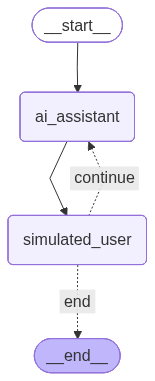

In [15]:
# 그래프 흐름: START → ai_assistant → simulated_user → (should_continue 분기) → ai_assistant 또는 END
# ai_assistant: 항공사 고객 상담 챗봇이 응답을 생성해요
# simulated_user: 가상 고객이 _swap_roles로 역할을 교환한 뒤 응답해요
# should_continue: 메시지 6개 초과 또는 FINISHED 신호 시 종료, 아니면 ai_assistant로 루프해요
from IPython.display import Image, display

display(Image(simulation.get_graph().draw_mermaid_png()))

## 8. 시뮬레이션 실행

드디어 시뮬레이션을 실행해요! 빈 메시지 대신 초기 사용자 메시지를 넣어서 상담사가 첫 번째 응답을 생성하게 해요.

> 🎯 **강의 포인트**: 실행 결과를 보면서 가상 고객이 얼마나 자연스럽게 행동하는지 확인해봐요. 상담사가 환불 거절을 어떻게 처리하는지, 고객이 어떻게 설득하려고 하는지 대화의 흐름이 흥미로워요.

In [16]:
# 시뮬레이션 실행
import uuid
from langchain_core.runnables import RunnableConfig

# 설정: 재귀 제한(무한 루프 방지)과 고유 스레드 ID
config = RunnableConfig(
    recursion_limit=10,  # 최대 10번 노드 실행 허용
    configurable={"thread_id": str(uuid.uuid4())}  # 각 실행마다 고유 ID
)

# 초기 입력: 화난 고객이 상담사에게 첫 마디를 건네는 상황
inputs = {
    "messages": [HumanMessage(content="안녕하세요? 저 지금 좀 화가 많이 났습니다!")]
}

# ============================================================
# 시뮬레이션 시작: 항공사 고객 상담
# 시나리오: 제주도 여행 전액 환불 요청
# ============================================================
print()

# 그래프 스트리밍 실행
# stream_mode="updates": 각 노드 실행 후 변경사항만 받아요
for chunk in simulation.stream(inputs, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        # 노드 이름에 따라 역할 표시
        if node_name == "ai_assistant":
            role_label = "[AI 상담사]"
        elif node_name == "simulated_user":
            role_label = "[고객 Alex]"
        else:
            continue

        # 메시지 출력
        if "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, 'content'):
                    content = msg.content
                elif isinstance(msg, tuple):
                    content = msg[1]  # (role, content) 형태
                else:
                    content = str(msg)
                print(f"{role_label} {content}")
                print()

# ============================================================
# 시뮬레이션 종료
# ============================================================

시뮬레이션 시작: 항공사 고객 상담
시나리오: 제주도 여행 전액 환불 요청

[AI 상담사] 안녕하세요. 고객님, 우선 불편을 드려서 정말 죄송합니다. 어떤 문제로 인해 화가 나셨는지 말씀해 주시면, 최선을 다해 도와드리겠습니다.

[고객 Alex] 작년에 제주도로 간 여행에 대한 환불 요청을 하고 싶습니다. 모든 돈을 다 돌려받고 싶습니다.

[AI 상담사] 고객님, 제주도로 가신 여행에 대한 환불 요청을 도와드리겠습니다. 환불 요청은 보통 항공권 구매 시의 규정에 따라 다르기 때문에 세부 사항을 확인해야 합니다. 

여행하신 날짜와 예약 번호를 알려주시면, 환불 절차에 대해 안내해 드리겠습니다. 또한, 환불 가능 여부에 대한 정보도 함께 확인해 드리겠습니다. 감사합니다.

[고객 Alex] 저의 여행 날짜는 2022년 9월 15일이었고, 예약 번호는 ABC123입니다. 환불이 절대적으로 필요합니다!

[AI 상담사] 고객님, 예약 번호 ABC123과 여행 날짜 2022년 9월 15일을 확인했습니다. 하지만 저희 항공사에서는 통상적으로 항공권 환불 요청은 구입한 요금 종류와 해당 날짜의 환불 정책에 따라 다르게 처리됩니다.

작년에 여행을 하셨다면, 환불 정책이 이미 적용되었을 가능성이 높습니다. 정확한 환불 가능 여부 및 절차를 확인하기 위해 고객님의 예약 정보를 좀 더 확인해야 합니다.

다시 한 번 말씀드리지만, 환불이 필요한 상황에 대해 정말 죄송합니다. 해당 예약에 대한 자세한 사항은 고객 서비스 센터를 통해 확인해주시면 보다 정확한 안내를 드릴 수 있을 것입니다. 필요한 경우, 전화나 이메일로 직접 문의하시면 신속하게 도와드리겠습니다. 감사합니다.

[고객 Alex] 그런데 저는 정말 모든 돈을 돌려받고 싶습니다! 어떤 방법으로든 해결해 주실 수 없나요?

시뮬레이션 종료


## 9. 다양한 시나리오 실험

시뮬레이션의 진짜 힘은 **다양한 시나리오를 손쉽게 만들 수 있다**는 거예요.

아래 TODO 블록에서 직접 시나리오를 바꿔보세요!

In [17]:
# ============================================================
# TODO: 새로운 시나리오를 만들어보세요!
# 힌트: create_scenario(name, instructions)의 instructions를
#       원하는 고객 상황으로 바꿔보세요
#
# 예시 시나리오 아이디어:
# 1. 수하물 분실 신고 고객
# 2. 항공편 지연으로 화난 고객
# 3. 마일리지 포인트 문의 고객
# 4. 좌석 업그레이드 요청 고객
#
# 예상 결과: 다른 상황에서 상담사가 어떻게 응답하는지 확인해요
# ============================================================

# 새 시나리오 설정 (아래 내용을 수정해보세요)
new_instructions = """You lost your luggage on a flight from Seoul to Busan. \
You are very frustrated and want immediate compensation."""

new_name = "Jin"

# 새 시뮬레이션된 사용자 생성
new_simulated_user = create_scenario(new_name, new_instructions)

# 기존 simulated_user를 새 시나리오로 교체
# (전역 변수를 덮어씌워서 simulated_user_node가 새 체인을 사용하게 해요)
simulated_user = new_simulated_user

# 새 설정으로 그래프 재실행
new_config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}  # 새 스레드 ID
)

new_inputs = {
    "messages": [HumanMessage(content="안녕하세요? 어떻게 도와드릴까요?")]
}

# ============================================================
print(f"새 시뮬레이션: {new_name}의 시나리오")
# ============================================================
print()

for chunk in simulation.stream(new_inputs, new_config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        if node_name == "ai_assistant":
            role_label = "[AI 상담사]"
        elif node_name == "simulated_user":
            role_label = f"[고객 {new_name}]"
        else:
            continue

        if "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, 'content'):
                    content = msg.content
                elif isinstance(msg, tuple):
                    content = msg[1]
                else:
                    content = str(msg)
                print(f"{role_label} {content}")
                print()

# ============================================================
# 시뮬레이션 종료
# ============================================================

새 시뮬레이션: Jin의 시나리오

[AI 상담사] 안녕하세요! 저희 항공사에 문의해 주셔서 감사합니다. 어떤 도움을 필요로 하시나요? 예약, 취소, 스케줄, 수하물 관련 질문 등 무엇이든 말씀해 주세요!

[고객 Jin] 안녕하세요. 저는 서울에서 부산으로 가는 비행기를 탔는데, 수하물이 분실되었습니다. 이 상황에 대해 매우 실망스럽고 즉각적인 보상을 원합니다. 어떻게 진행하면 좋을까요?

[AI 상담사] 안녕하세요. 수하물 분실로 인해 불편을 드려 정말 죄송합니다. 고객님의 불만을 이해하며, 최대한 빠르게 도움을 드리겠습니다.

먼저, 수하물 분실 신고서를 작성해 주셔야 합니다. 공항의 수하물 보상 센터나 고객 서비스 팀으로 가셔서 신고를 하실 수 있습니다. 신고서를 작성하신 후, 수하물의 추적을 시작할 수 있습니다.

또한, 수하물 분실에 대한 보상은 항공사 정책에 따라 다르게 적용될 수 있으니, 필요한 서류와 정보를 준비해 주시기 바랍니다. 

고객센터에 직접 문의하시면 구체적인 진행 절차와 추가 정보를 안내해 드릴 수 있습니다. 다시 한 번 불편을 드려 죄송하며, 신속히 문제를 해결할 수 있도록 최선을 다하겠습니다.

[고객 Jin] 신고서를 작성하는 것이 첫 단계라는 것을 알겠습니다. 그러나 이 모든 과정을 기다리는 동안 너무 많은 시간이 지날까 두렵습니다. 보상 절차가 얼마나 걸리는지, 그리고 제가 즉각적으로 보상을 받을 수 있는 방법이 있는지 알고 싶습니다.

[AI 상담사] 고객님의 걱정을 이해합니다. 수하물 분실 사건에 대한 보상 절차는 항공사마다 다소 차이가 있지만, 일반적으로 수하물 신고서를 제출한 후 처리하는 데 몇 일에서 몇 주가 소요될 수 있습니다.

즉각적인 보상을 받으시는 것은 어렵지만, 항공사는 보상 신청이 승인되면 최대한 신속하게 처리하려고 노력합니다. 보상 금액은 수하물의 가치와 분실 상태에 따라 달라질 수 있습니다.

일부 항공사에서는 수하물 분실로 인한 긴급 필요 비용(예: 의류, 세면도구 등)을 보상하기 위한 특별 절차

## 10. 시뮬레이션 결과 분석

단순 실행을 넘어 대화 결과를 분석하는 방법도 알아봐요.

In [18]:
# 시뮬레이션 결과를 수집하고 분석하는 도우미 함수
def run_simulation_and_collect(scenario_name: str, scenario_instructions: str, initial_message: str) -> dict:
    """시뮬레이션을 실행하고 결과를 수집해요.

    Args:
        scenario_name: 가상 고객 이름
        scenario_instructions: 고객 지시사항
        initial_message: 시뮬레이션 시작 메시지

    Returns:
        대화 이력과 통계가 담긴 딕셔너리
    """
    global simulated_user  # 전역 simulated_user 업데이트

    # 새 시뮬레이션된 사용자 생성
    simulated_user = create_scenario(scenario_name, scenario_instructions)

    # 설정
    run_config = RunnableConfig(
        recursion_limit=15,
        configurable={"thread_id": str(uuid.uuid4())}
    )

    inputs = {"messages": [HumanMessage(content=initial_message)]}

    # 대화 이력 수집
    conversation = []
    assistant_turns = 0
    customer_turns = 0
    finished_normally = False

    for chunk in simulation.stream(inputs, run_config, stream_mode="updates"):
        for node_name, node_output in chunk.items():
            if "messages" in node_output:
                for msg in node_output["messages"]:
                    # 메시지 내용 추출
                    if hasattr(msg, 'content'):
                        content = msg.content
                    elif isinstance(msg, tuple):
                        content = msg[1]
                    else:
                        content = str(msg)

                    # FINISHED 신호 감지
                    if content == "FINISHED":
                        finished_normally = True

                    conversation.append({
                        "role": node_name,
                        "content": content
                    })

                    if node_name == "ai_assistant":
                        assistant_turns += 1
                    elif node_name == "simulated_user":
                        customer_turns += 1

    return {
        "scenario": scenario_name,
        "conversation": conversation,
        "total_turns": assistant_turns + customer_turns,
        "assistant_turns": assistant_turns,
        "customer_turns": customer_turns,
        "finished_normally": finished_normally,
    }

In [19]:
# 시뮬레이션 실행 및 결과 분석
# 원래 시나리오(제주도 환불)로 돌아가서 분석해봐요

result = run_simulation_and_collect(
    scenario_name="Alex",
    scenario_instructions="""You are trying to get a refund for the trip you took to Jeju Island. \
You want them to give you ALL the money back. This trip happened last year.""",
    initial_message="안녕하세요? 저 환불 문제로 전화했는데요."
)

# 결과 출력
# ============================================================
print(f"시나리오: {result['scenario']} 고객")
# ============================================================
print(f"총 대화 턴 수: {result['total_turns']}")
print(f"상담사 응답: {result['assistant_turns']}회")
print(f"고객 발언: {result['customer_turns']}회")
print(f"정상 종료(FINISHED): {'예' if result['finished_normally'] else '아니오 (메시지 수 초과)'}")
print()
# [전체 대화 이력]
# ------------------------------------------------------------
for turn in result['conversation']:
    role = "[AI 상담사]" if turn['role'] == 'ai_assistant' else "[고객 Alex]"
    if turn['content'] != 'FINISHED':
        print(f"{role}")
        print(f"{turn['content']}")
        print()

시나리오: Alex 고객
총 대화 턴 수: 6
상담사 응답: 3회
고객 발언: 3회
정상 종료(FINISHED): 아니오 (메시지 수 초과)

[전체 대화 이력]
------------------------------------------------------------
[AI 상담사]
안녕하세요! 고객님, 환불 문제로 연락 주셔서 감사합니다. 어떤 점에서 도움이 필요하신지 말씀해 주시면, 최선을 다해 도와드리겠습니다.

[고객 Alex]
작년 제주도로 여행을 갔었는데, 그 여행에 대해 전액 환불을 요청하고 싶습니다. 어떤 절차를 밟아야 하나요?

[AI 상담사]
고객님, 제주도로의 여행에 대한 환불 요청을 도와드리겠습니다. 전액 환불을 요청하시려면 다음과 같은 절차를 따라주시면 됩니다.

1. **예약 확인**: 고객님의 예약 번호와 비행 정보를 준비해 주세요.
2. **환불 요청 양식 작성**: 저희 웹사이트나 고객 서비스 센터에서 환불 요청 양식을 다운로드하거나 요청하실 수 있습니다.
3. **필요 서류 제출**: 양식을 작성한 후, 모든 관련 서류(예: 항공권, 결제 영수증 등)를 함께 제출해 주세요.
4. **제출 방법**: 작성한 양식과 서류를 고객 서비스 센터에 이메일로 보내시거나 직접 방문하여 제출하실 수 있습니다.
5. **환불 처리**: 제출하신 후에는 환불 처리에 보통 7~10일 정도 소요됩니다.

자세한 내용이나 추가 도움이 필요하시면 언제든지 말씀해 주세요. 감사합니다!

[고객 Alex]
저는 여행을 갔던 것이 매우 특별했기 때문에 전액 환불이 필요합니다. 어떻게든 이 절차를 통해 완전한 환불을 받을 수 있도록 도와주실 수 있나요?

[AI 상담사]
고객님, 특별한 여행이었음을 이해합니다. 전액 환불을 원하시는 경우, 저희는 최선을 다해 지원해 드리겠습니다. 하지만 환불 정책은 항공권의 종류, 취소 사유에 따라 다를 수 있습니다.

1. **환불 정책 확인**: 고객님의 예약 내용에 따라 가능한 환불 옵션을 확인해 보겠습니다. 예약 정

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **에이전트 시뮬레이션**: LLM을 가상 고객으로 만들어 챗봇을 자동으로 평가하는 기법이에요. 수동 테스트 없이도 다양한 시나리오를 빠르게 검증할 수 있어요.
- **`_swap_roles`**: 두 LLM이 대화할 때 발생하는 역할 혼란을 해결해요. AIMessage ↔ HumanMessage를 상호 변환해서 각 LLM이 올바른 관점으로 대화를 인식하게 해요.
- **`create_scenario`**: 이름과 지시사항을 파라미터로 받아 다양한 가상 고객을 손쉽게 생성해요. 환불 요청부터 수하물 분실, 항공편 지연까지 어떤 시나리오든 만들 수 있어요.
- **`should_continue`**: 조건부 엣지 함수로 시뮬레이션 종료를 제어해요. 메시지 수 제한(무한 루프 방지)과 FINISHED 신호(정상 종료) 두 가지 방식을 사용해요.
- **양방향 StateGraph**: `ai_assistant → simulated_user → (조건부) → ai_assistant` 순환 구조로 실제 대화를 완벽하게 시뮬레이션해요.

## 다음 노트북 예고

다음 `05-Prompt-Generation.ipynb`에서는 **요구사항 수집 후 시스템 프롬프트를 자동 생성하는 에이전트**를 배워요. 사용자와 대화하며 작업 목표·제약·예시를 수집하고, 그 정보로 **잘 설계된 시스템 프롬프트를 역으로 만들어내는 메타 에이전트**예요. 프롬프트 엔지니어링 자체를 에이전트에게 위임하는 재미있는 사례예요.

<!-- AUTOPILOT_CREATE_AGENT_DEEP_AGENT_APPENDIX -->
## 보강: `create_agent`로 시뮬레이션 대상 상담사를 상태 머신화하기

### 참고 공식 문서
- [Build customer support with handoffs](https://docs.langchain.com/oss/python/langchain/multi-agent/handoffs-customer-support)
- [LangChain Agents middleware](https://docs.langchain.com/oss/python/langchain/agents)

본문은 `StateGraph`로 **AI 상담사 ↔ 가상 고객** 두 역할을 번갈아 실행하며 `_swap_roles`가 왜 필요한지 보여줍니다. 이 방식은 시뮬레이션 루프를 이해하기 좋지만, 실제 고객지원 봇을 만들 때는 상담사의 상태 전이를 `create_agent`의 middleware와 checkpointer로 단순화할 수 있어요.

공식 customer-support handoffs 문서의 핵심은 다음과 같습니다.

- 하나의 `create_agent`가 여러 단계의 상담사 역할을 수행해요.
- 도구가 `current_step` 같은 상태 값을 업데이트해 다음 단계로 전이해요.
- `@wrap_model_call` middleware가 현재 단계에 맞는 system prompt와 도구 목록을 동적으로 주입해요.
- `InMemorySaver` 같은 checkpointer가 여러 턴의 상담 상태를 유지해요.

따라서 고도화 방향은 다음처럼 나눌 수 있어요.

| 목적 | 권장 방식 |
|---|---|
| 시뮬레이션 루프와 role swapping 원리 학습 | 본문의 `StateGraph` |
| 실제 상담사의 단계별 정책/도구 전환 | `create_agent` + middleware |
| 많은 시나리오 자동 평가 | 가상 고객은 `create_agent`, 평가자는 LangSmith/evaluator로 분리 |

아래 예시는 상담사 자체를 `create_agent` 상태 머신으로 만들고, 기존 시뮬레이션 루프에서 평가 대상으로 연결하는 방향을 보여줍니다.


In [ ]:
# ============================================================
# 선택 실행: create_agent 기반 고객지원 상태 머신 상담사
# ============================================================
# 외부 모델 호출이 필요하므로 기본값은 False예요.
RUN_CREATE_AGENT_SIMULATION_APPENDIX = False

if RUN_CREATE_AGENT_SIMULATION_APPENDIX:
    from typing import Callable, Literal
    from typing_extensions import NotRequired

    from langchain.agents import AgentState, create_agent
    from langchain.agents.middleware import ModelRequest, ModelResponse, wrap_model_call
    from langchain.chat_models import init_chat_model
    from langchain_core.messages import HumanMessage, ToolMessage
    from langchain.tools import ToolRuntime, tool
    from langgraph.checkpoint.memory import InMemorySaver
    from langgraph.types import Command

    # --------------------------------------------------------
    # 1) 상담 단계 상태 정의
    # --------------------------------------------------------
    SupportStep = Literal["triage", "refund_check", "resolution"]

    class SupportSimulationState(AgentState):
        """고객지원 상담사의 장기 대화 상태."""
        current_step: NotRequired[SupportStep]
        issue_type: NotRequired[str]
        refund_eligible: NotRequired[bool]

    # --------------------------------------------------------
    # 2) 상태를 변경하는 도구
    # --------------------------------------------------------
    @tool
    def classify_issue(
        issue_type: Literal["refund", "lost_item", "delay", "other"],
        runtime: ToolRuntime[None, SupportSimulationState],
    ) -> Command:
        """Classify the customer issue and move to the right support step."""
        next_step = "refund_check" if issue_type == "refund" else "resolution"
        return Command(update={
            "issue_type": issue_type,
            "current_step": next_step,
            "messages": [ToolMessage(
                content=f"Issue classified as {issue_type}; next step is {next_step}.",
                tool_call_id=runtime.tool_call_id,
            )],
        })

    @tool
    def record_refund_eligibility(
        eligible: bool,
        runtime: ToolRuntime[None, SupportSimulationState],
    ) -> Command:
        """Record whether the refund policy allows a refund and move to resolution."""
        return Command(update={
            "refund_eligible": eligible,
            "current_step": "resolution",
            "messages": [ToolMessage(
                content=f"Refund eligibility recorded: {eligible}",
                tool_call_id=runtime.tool_call_id,
            )],
        })

    @tool
    def provide_resolution(summary: str) -> str:
        """Provide the final support resolution to the customer."""
        return summary

    # --------------------------------------------------------
    # 3) 단계별 프롬프트/도구 구성
    # --------------------------------------------------------
    STEP_CONFIG = {
        "triage": {
            "prompt": "너는 친절한 여행 고객지원 상담사다. 먼저 문제 유형을 파악하고 classify_issue를 호출한다.",
            "tools": [classify_issue],
        },
        "refund_check": {
            "prompt": "환불 정책 담당자다. 여행일, 약관, 예외 사유를 확인하고 record_refund_eligibility를 호출한다.",
            "tools": [record_refund_eligibility],
        },
        "resolution": {
            "prompt": "해결 담당자다. 현재 상태를 바탕으로 한국어로 명확한 다음 조치를 안내하고 provide_resolution을 호출한다.",
            "tools": [provide_resolution],
        },
    }

    @wrap_model_call
    def apply_support_step(
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        """현재 current_step에 따라 상담사의 프롬프트와 사용 가능한 도구를 바꿔요."""
        current_step = request.state.get("current_step", "triage")
        cfg = STEP_CONFIG[current_step]
        request = request.override(
            system_prompt=cfg["prompt"],
            tools=cfg["tools"],
        )
        return handler(request)

    # --------------------------------------------------------
    # 4) create_agent 상담사 생성
    # --------------------------------------------------------
    support_agent = create_agent(
        model=init_chat_model("openai:gpt-4o-mini", temperature=0),
        tools=[classify_issue, record_refund_eligibility, provide_resolution],
        state_schema=SupportSimulationState,
        middleware=[apply_support_step],
        checkpointer=InMemorySaver(),
    )

    # 기존 시뮬레이션 루프에서 support_agent.invoke(...)를 상담사 응답 생성기로 사용하면 돼요.
    config = {"configurable": {"thread_id": "simulation-support-demo"}}
    result = support_agent.invoke(
        {"messages": [HumanMessage(content="작년에 다녀온 제주도 여행을 전액 환불받고 싶어요.")]},
        config=config,
    )
    print(result["messages"][-1].content)
